In [22]:
#Libraries
import os
import random
import numpy as np
import pandas as pd
import torch
import re
import torch.nn as nn
from transformers import AutoModel
from transformers import AutoTokenizer
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding
import math
import copy
from torch.optim import AdamW

In [2]:
#Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Seed: 42
PyTorch: 2.11.0+cu128
CUDA available: True


In [3]:
#Load datasets
train_df = pd.read_csv("/content/phishing_train.csv")
val_df   = pd.read_csv("/content/phishing_validation.csv")
test_df  = pd.read_csv("/content/phishing_test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)

Train labels:
label
0    8782
1    5233
Name: count, dtype: int64

Validation labels:
label
0    1098
1     654
Name: count, dtype: int64

Test labels:
label
0    1098
1     654
Name: count, dtype: int64


In [5]:
#Generate NLP features
URGENCY_TERMS = [
    "urgent", "urgently", "immediately", "immediate", "now",
    "today", "asap", "quickly", "deadline", "expire",
    "expired", "final", "action"
]

CREDENTIAL_TERMS = [
    "password", "passwd", "username", "login", "credential",
    "credentials", "verify", "verification", "authenticate",
    "authentication", "account"
]

THREAT_TERMS = [
    "suspend", "suspended", "terminate", "terminated", "blocked",
    "block", "close", "closed", "penalty", "fraud",
    "unauthorized", "warning", "security"
]

FINANCIAL_TERMS = [
    "payment", "pay", "invoice", "money", "bank", "transfer",
    "transaction", "refund", "credit", "debit", "fee",
    "account", "billing"
]

CTA_TERMS = [
    "click", "clicking", "visit", "open", "download", "confirm",
    "verify", "submit", "update", "activate", "login"
]

In [6]:
#Set feature extraction function
def extract_nlp_features(text):

    text = str(text)

    words = re.findall(
        r"\b\w+\b",
        text.lower()
    )

    # 1. Urgency term count
    urgency_count = sum(
        word in URGENCY_TERMS
        for word in words
    )

    # 2. Credential-related term count
    credential_count = sum(
        word in CREDENTIAL_TERMS
        for word in words
    )

    # 3. Threat/authority term count
    threat_count = sum(
        word in THREAT_TERMS
        for word in words
    )

    # 4. Financial/payment term count
    financial_count = sum(
        word in FINANCIAL_TERMS
        for word in words
    )

    # 5. Call-to-action term count
    cta_count = sum(
        word in CTA_TERMS
        for word in words
    )

    # 6. URL count
    url_count = len(
        re.findall(
            r"https?://\S+|www\.\S+",
            text,
            flags=re.IGNORECASE
        )
    )

    # 7. Email address count
    email_count = len(
        re.findall(
            r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
            text
        )
    )

    # 8. Phone number count
    phone_count = len(
        re.findall(
            r"\b(?:\+?\d[\d\s().-]{7,}\d)\b",
            text
        )
    )

    # 9. Exclamation count
    exclamation_count = text.count("!")

    # 10. Question count
    question_count = text.count("?")

    # 11. Uppercase-word ratio
    all_words = re.findall(
        r"\b[A-Za-z]+\b",
        text
    )

    if len(all_words) > 0:
        uppercase_ratio = sum(
            word.isupper() and len(word) > 1
            for word in all_words
        ) / len(all_words)
    else:
        uppercase_ratio = 0.0

    # 12. Log-transformed text length
    log_text_length = np.log1p(len(text))

    return [
        urgency_count,
        credential_count,
        threat_count,
        financial_count,
        cta_count,
        url_count,
        email_count,
        phone_count,
        exclamation_count,
        question_count,
        uppercase_ratio,
        log_text_length
    ]

In [7]:
for current_df in [train_df, val_df, test_df]:

    current_df["nlp_features"] = current_df[
        "processed_text"
    ].apply(extract_nlp_features)

# Feature names
feature_names = [
    "urgency_count",
    "credential_count",
    "threat_count",
    "financial_count",
    "cta_count",
    "url_count",
    "email_count",
    "phone_count",
    "exclamation_count",
    "question_count",
    "uppercase_ratio",
    "log_text_length"
]

# Verify
print("Number of features:",
      len(train_df["nlp_features"].iloc[0]))

print("\nFeature names:")
for i, name in enumerate(feature_names, start=1):
    print(i, name)

print("\nExample feature vector:")
print(train_df["nlp_features"].iloc[0])

Number of features: 12

Feature names:
1 urgency_count
2 credential_count
3 threat_count
4 financial_count
5 cta_count
6 url_count
7 email_count
8 phone_count
9 exclamation_count
10 question_count
11 uppercase_ratio
12 log_text_length

Example feature vector:
[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0.0, np.float64(6.368187186350492)]


In [8]:
# Convert feature lists to NumPy arrays
X_train_features = np.array(
    train_df["nlp_features"].tolist(),
    dtype=np.float32
)

X_val_features = np.array(
    val_df["nlp_features"].tolist(),
    dtype=np.float32
)

X_test_features = np.array(
    test_df["nlp_features"].tolist(),
    dtype=np.float32
)

# Calculate statistics ONLY from training data

feature_mean = X_train_features.mean(axis=0)
feature_std = X_train_features.std(axis=0)

# Avoid division by zero
feature_std[feature_std == 0] = 1.0


# Standardize all datasets using training statistics

X_train_features = (
    X_train_features - feature_mean
) / feature_std

X_val_features = (
    X_val_features - feature_mean
) / feature_std

X_test_features = (
    X_test_features - feature_mean
) / feature_std


# Verify


print("Train feature shape:", X_train_features.shape)
print("Validation feature shape:", X_val_features.shape)
print("Test feature shape:", X_test_features.shape)

print("\nTraining means after normalization:")
print(np.round(X_train_features.mean(axis=0), 4))

print("\nTraining standard deviations:")
print(np.round(X_train_features.std(axis=0), 4))

Train feature shape: (14015, 12)
Validation feature shape: (1752, 12)
Test feature shape: (1752, 12)

Training means after normalization:
[-0. -0. -0. -0.  0. -0. -0.  0. -0.  0.  0.  0.]

Training standard deviations:
[1.     0.9999 1.0001 1.     0.9999 0.9999 1.0001 1.     1.0002 1.
 1.     1.    ]


In [10]:
#Tokenize
MODEL_NAME = "distilbert/distilbert-base-uncased"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

# Tokenize each split
train_encodings = tokenize_texts(
    train_df["processed_text"]
)

val_encodings = tokenize_texts(
    val_df["processed_text"]
)

test_encodings = tokenize_texts(
    test_df["processed_text"]
)

print("Tokenization completed.")

print("\nTrain samples:", len(train_encodings["input_ids"]))
print("Validation samples:", len(val_encodings["input_ids"]))
print("Test samples:", len(test_encodings["input_ids"]))

print("\nExample tokenized length:")
print(len(train_encodings["input_ids"][0]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization completed.

Train samples: 14015
Validation samples: 1752
Test samples: 1752

Example tokenized length:
131


In [12]:
class PhishingHybridDataset(Dataset):

    def __init__(
        self,
        encodings,
        features,
        labels
    ):
        self.encodings = encodings
        self.features = features
        self.labels = np.asarray(
            labels,
            dtype=np.int64
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            "input_ids": torch.tensor(
                self.encodings["input_ids"][idx],
                dtype=torch.long
            ),

            "attention_mask": torch.tensor(
                self.encodings["attention_mask"][idx],
                dtype=torch.long
            ),

            "nlp_features": torch.tensor(
                self.features[idx],
                dtype=torch.float32
            ),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

        return item


# Create datasets

train_dataset = PhishingHybridDataset(
    train_encodings,
    X_train_features,
    train_df["label"].values
)

val_dataset = PhishingHybridDataset(
    val_encodings,
    X_val_features,
    val_df["label"].values
)

test_dataset = PhishingHybridDataset(
    test_encodings,
    X_test_features,
    test_df["label"].values
)

# Verify

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

sample = train_dataset[0]

print("\nSample:")
for key, value in sample.items():
    print(
        key,
        value.shape,
        value.dtype
    )

Train: 14015
Validation: 1752
Test: 1752

Sample:
input_ids torch.Size([131]) torch.int64
attention_mask torch.Size([131]) torch.int64
nlp_features torch.Size([12]) torch.float32
labels torch.Size([]) torch.int64


In [14]:
#Dataloader
# Tokenizer-based dynamic padding
padding_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)


def hybrid_collate_fn(batch):

    # Separate token information
    token_features = [
        {
            "input_ids": item["input_ids"],
            "attention_mask": item["attention_mask"]
        }
        for item in batch
    ]

    # Dynamic padding
    token_batch = padding_collator(
        token_features
    )

    # Add NLP features
    token_batch["nlp_features"] = torch.stack(
        [
            item["nlp_features"]
            for item in batch
        ]
    )

    # Add labels
    token_batch["labels"] = torch.stack(
        [
            item["labels"]
            for item in batch
        ]
    )

    return token_batch


# DataLoader configuration

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=hybrid_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=hybrid_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=hybrid_collate_fn
)

print("DataLoaders created.")

DataLoaders created.


In [15]:
batch = next(iter(train_loader))

print("Batch contents:")

for key, value in batch.items():
    print(
        key,
        value.shape,
        value.dtype
    )

Batch contents:
input_ids torch.Size([16, 512]) torch.int64
attention_mask torch.Size([16, 512]) torch.int64
nlp_features torch.Size([16, 12]) torch.float32
labels torch.Size([16]) torch.int64


In [20]:
#Model design

class DistilBERTGatedHybrid(nn.Module):

    def __init__(
        self,
        model_name,
        num_features=12,
        feature_dim=256
    ):
        super().__init__()

        self.transformer = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.float32
        )

        hidden_size = self.transformer.config.hidden_size

        self.context_projection = nn.Sequential(
            nn.Linear(hidden_size, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.feature_projection = nn.Sequential(
            nn.Linear(num_features, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.gate = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.Sigmoid()
        )

        self.fusion = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.classifier = nn.Linear(feature_dim, 2)

    def forward(
        self,
        input_ids,
        attention_mask,
        nlp_features,
        labels=None
    ):

        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        contextual_embedding = outputs.last_hidden_state[:, 0, :]

        context = self.context_projection(
            contextual_embedding
        )

        features = self.feature_projection(
            nlp_features.float()
        )

        combined = torch.cat(
            [context, features],
            dim=1
        )

        gate = self.gate(combined)

        fused = (
            gate * context
            + (1 - gate) * features
        )

        fused = self.fusion(fused)

        logits = self.classifier(fused)

        loss = None

        if labels is not None:
            loss = nn.CrossEntropyLoss()(
                logits,
                labels.long()
            )

        return {
            "loss": loss,
            "logits": logits
        }


model = DistilBERTGatedHybrid(
    model_name=MODEL_NAME,
    num_features=12,
    feature_dim=256
)

print("Draft 4 model created successfully.")
print("DistilBERT hidden size:",
      model.transformer.config.hidden_size)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Draft 4 model created successfully.
DistilBERT hidden size: 768


In [21]:
#Check

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

model = model.to(device)

# Get one real training batch
batch = next(iter(train_loader))

# Move batch to GPU
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
nlp_features = batch["nlp_features"].to(device)
labels = batch["labels"].to(device)

# Forward pass
outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    nlp_features=nlp_features,
    labels=labels
)

print("\nForward pass successful.")

print("Logits shape:", outputs["logits"].shape)
print("Loss:", outputs["loss"].item())

# Backward pass
outputs["loss"].backward()

print("Backward pass successful.")

# Clear gradients
model.zero_grad(set_to_none=True)

print("\n✓ Model and training batch verified.")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Forward pass successful.
Logits shape: torch.Size([16, 2])
Loss: 0.6955388784408569
Backward pass successful.

✓ Model and training batch verified.


In [23]:
#Model training setup

import math
import copy
import torch
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#Training config
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 263
MAX_GRAD_NORM = 1.0

#Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

#Training steps
steps_per_epoch = len(train_loader)

total_training_steps = (
    steps_per_epoch * EPOCHS
)

print("Steps per epoch:", steps_per_epoch)
print("Total training steps:", total_training_steps)
print("Warmup steps:", WARMUP_STEPS)


scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_training_steps
)


def evaluate_model(model, data_loader, device):

    model.eval()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            nlp_features = batch["nlp_features"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                nlp_features=nlp_features,
                labels=labels
            )

            total_loss += (
                outputs["loss"].item()
                * labels.size(0)
            )

            predictions = torch.argmax(
                outputs["logits"],
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    avg_loss = (
        total_loss / len(data_loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


#Training
best_val_f1 = -1.0
best_model_state = None

training_history = []

for epoch in range(EPOCHS):

    model.train()

    total_train_loss = 0.0

    for step, batch in enumerate(train_loader):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        nlp_features = batch["nlp_features"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            nlp_features=nlp_features,
            labels=labels
        )

        loss = outputs["loss"]

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM
        )

        # Update weights
        optimizer.step()
        scheduler.step()

        # Clear gradients
        optimizer.zero_grad(set_to_none=True)

        total_train_loss += (
            loss.item() * labels.size(0)
        )

        # Progress
        if (step + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}/{EPOCHS} | "
                f"Step {step + 1}/{steps_per_epoch} | "
                f"Loss: {loss.item():.4f}"
            )

    # Average training loss
    train_loss = (
        total_train_loss
        / len(train_loader.dataset)
    )

    # Validation
    val_metrics = evaluate_model(
        model,
        val_loader,
        device
    )

    # Store results
    epoch_result = {
        "epoch": epoch + 1,
        "training_loss": train_loss,
        "validation_loss": val_metrics["loss"],
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"]
    }

    training_history.append(epoch_result)

    print("\n" + "=" * 65)
    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )
    print(
        f"Training Loss:   {train_loss:.4f}"
    )
    print(
        f"Validation Loss: {val_metrics['loss']:.4f}"
    )
    print(
        f"Accuracy:        {val_metrics['accuracy']:.4f}"
    )
    print(
        f"Precision:       {val_metrics['precision']:.4f}"
    )
    print(
        f"Recall:          {val_metrics['recall']:.4f}"
    )
    print(
        f"F1:              {val_metrics['f1']:.4f}"
    )
    print("=" * 65)

    #Model save
    if val_metrics["f1"] > best_val_f1:

        best_val_f1 = val_metrics["f1"]

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"✓ New best model saved "
            f"(Validation F1 = {best_val_f1:.4f})"
        )


model.load_state_dict(best_model_state)

print("\n" + "=" * 65)
print("Training completed.")
print(
    f"Best validation F1: {best_val_f1:.4f}"
)
print("=" * 65)

Steps per epoch: 876
Total training steps: 2628
Warmup steps: 263
Epoch 1/3 | Step 100/876 | Loss: 0.6995
Epoch 1/3 | Step 200/876 | Loss: 0.3036
Epoch 1/3 | Step 300/876 | Loss: 0.0748
Epoch 1/3 | Step 400/876 | Loss: 0.0256
Epoch 1/3 | Step 500/876 | Loss: 0.1025
Epoch 1/3 | Step 600/876 | Loss: 0.0212
Epoch 1/3 | Step 700/876 | Loss: 0.0071
Epoch 1/3 | Step 800/876 | Loss: 0.0166

Epoch 1/3
Training Loss:   0.2170
Validation Loss: 0.1054
Accuracy:        0.9743
Precision:       0.9445
Recall:          0.9893
F1:              0.9664
✓ New best model saved (Validation F1 = 0.9664)
Epoch 2/3 | Step 100/876 | Loss: 0.0055
Epoch 2/3 | Step 200/876 | Loss: 0.0040
Epoch 2/3 | Step 300/876 | Loss: 0.0015
Epoch 2/3 | Step 400/876 | Loss: 0.4157
Epoch 2/3 | Step 500/876 | Loss: 0.0028
Epoch 2/3 | Step 600/876 | Loss: 0.0815
Epoch 2/3 | Step 700/876 | Loss: 0.0014
Epoch 2/3 | Step 800/876 | Loss: 0.0009

Epoch 2/3
Training Loss:   0.0427
Validation Loss: 0.0669
Accuracy:        0.9869
Precisio

In [24]:
#Test evaluation ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_metrics = evaluate_model(
    model,
    test_loader,
    device
)

print("=" * 60)
print("DRAFT 4 — TEST RESULTS")
print("=" * 60)

print(f"Test Loss:      {test_metrics['loss']:.4f}")
print(f"Accuracy:       {test_metrics['accuracy']:.4f}")
print(f"Precision:      {test_metrics['precision']:.4f}")
print(f"Recall:         {test_metrics['recall']:.4f}")
print(f"F1:             {test_metrics['f1']:.4f}")

DRAFT 4 — TEST RESULTS
Test Loss:      0.0382
Accuracy:       0.9897
Precision:      0.9818
Recall:         0.9908
F1:             0.9863


In [25]:
#Report and confusion matrix
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        nlp_features = batch["nlp_features"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            nlp_features=nlp_features
        )

        predictions = torch.argmax(
            outputs["logits"],
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Safe Email",
            "Phishing Email"
        ],
        digits=4
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_predictions
    )
)


Classification Report:
                precision    recall  f1-score   support

    Safe Email     0.9945    0.9891    0.9918      1098
Phishing Email     0.9818    0.9908    0.9863       654

      accuracy                         0.9897      1752
     macro avg     0.9882    0.9899    0.9890      1752
  weighted avg     0.9898    0.9897    0.9897      1752

Confusion Matrix:
[[1086   12]
 [   6  648]]


In [26]:
# ============================================================
# TINYBERT + NLP FEATURES + GATED FUSION
# COMPLETE EXPERIMENT
# ============================================================

import os
import re
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup

from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 70)
print("TINYBERT GATED HYBRID EXPERIMENT")
print("=" * 70)

print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ============================================================
# 2. LOAD DATASETS
# ============================================================

train_df = pd.read_csv(
    "/content/phishing_train.csv"
)

val_df = pd.read_csv(
    "/content/phishing_validation.csv"
)

test_df = pd.read_csv(
    "/content/phishing_test.csv"
)

print("\nDataset sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

# ============================================================
# 3. DETERMINE TEXT AND LABEL COLUMNS
# ============================================================

# Use processed_text if available
if "processed_text" in train_df.columns:
    TEXT_COLUMN = "processed_text"
elif "Email Text" in train_df.columns:
    TEXT_COLUMN = "Email Text"
else:
    raise ValueError(
        "No suitable text column found."
    )

# Use label if available
if "label" in train_df.columns:

    LABEL_COLUMN = "label"

else:

    if "Email Type" not in train_df.columns:
        raise ValueError(
            "No suitable label column found."
        )

    # Convert original labels
    label_map = {
        "Safe Email": 0,
        "Phishing Email": 1
    }

    for current_df in [
        train_df,
        val_df,
        test_df
    ]:
        current_df["label"] = (
            current_df["Email Type"]
            .map(label_map)
        )

    LABEL_COLUMN = "label"

# Make labels integer
train_df[LABEL_COLUMN] = (
    train_df[LABEL_COLUMN]
    .astype(np.int64)
)

val_df[LABEL_COLUMN] = (
    val_df[LABEL_COLUMN]
    .astype(np.int64)
)

test_df[LABEL_COLUMN] = (
    test_df[LABEL_COLUMN]
    .astype(np.int64)
)

# Check missing values
if train_df[TEXT_COLUMN].isna().any():
    raise ValueError("Missing training text detected.")

if val_df[TEXT_COLUMN].isna().any():
    raise ValueError("Missing validation text detected.")

if test_df[TEXT_COLUMN].isna().any():
    raise ValueError("Missing test text detected.")

if train_df[LABEL_COLUMN].isna().any():
    raise ValueError("Missing training labels detected.")

if val_df[LABEL_COLUMN].isna().any():
    raise ValueError("Missing validation labels detected.")

if test_df[LABEL_COLUMN].isna().any():
    raise ValueError("Missing test labels detected.")

print("\nText column:", TEXT_COLUMN)
print("Label column:", LABEL_COLUMN)

print("\nLabel distribution:")
print(
    train_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

# ============================================================
# 4. 12 PHISHING-ORIENTED NLP FEATURES
# ============================================================

URGENCY_TERMS = [
    "urgent", "urgently", "immediately", "immediate",
    "now", "today", "asap", "quickly", "deadline",
    "expire", "expired", "final", "action"
]

CREDENTIAL_TERMS = [
    "password", "passwd", "username", "login",
    "credential", "credentials", "verify",
    "verification", "authenticate", "authentication",
    "account"
]

THREAT_TERMS = [
    "suspend", "suspended", "terminate", "terminated",
    "blocked", "block", "close", "closed", "penalty",
    "fraud", "unauthorized", "warning", "security"
]

FINANCIAL_TERMS = [
    "payment", "pay", "invoice", "money", "bank",
    "transfer", "transaction", "refund", "credit",
    "debit", "fee", "account", "billing"
]

CTA_TERMS = [
    "click", "clicking", "visit", "open", "download",
    "confirm", "verify", "submit", "update",
    "activate", "login"
]


def extract_nlp_features(text):

    text = str(text)

    words = re.findall(
        r"\b\w+\b",
        text.lower()
    )

    # 1. Urgency term count
    urgency_count = sum(
        word in URGENCY_TERMS
        for word in words
    )

    # 2. Credential term count
    credential_count = sum(
        word in CREDENTIAL_TERMS
        for word in words
    )

    # 3. Threat/authority term count
    threat_count = sum(
        word in THREAT_TERMS
        for word in words
    )

    # 4. Financial/payment term count
    financial_count = sum(
        word in FINANCIAL_TERMS
        for word in words
    )

    # 5. Call-to-action term count
    cta_count = sum(
        word in CTA_TERMS
        for word in words
    )

    # 6. URL count
    url_count = len(
        re.findall(
            r"https?://\S+|www\.\S+",
            text,
            flags=re.IGNORECASE
        )
    )

    # 7. Email address count
    email_count = len(
        re.findall(
            r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
            text
        )
    )

    # 8. Phone number count
    phone_count = len(
        re.findall(
            r"\b(?:\+?\d[\d\s().-]{7,}\d)\b",
            text
        )
    )

    # 9. Exclamation count
    exclamation_count = text.count("!")

    # 10. Question count
    question_count = text.count("?")

    # 11. Uppercase-word ratio
    all_words = re.findall(
        r"\b[A-Za-z]+\b",
        text
    )

    if len(all_words) > 0:

        uppercase_ratio = (
            sum(
                word.isupper() and len(word) > 1
                for word in all_words
            )
            / len(all_words)
        )

    else:

        uppercase_ratio = 0.0

    # 12. Log-transformed text length
    log_text_length = np.log1p(
        len(text)
    )

    return [
        urgency_count,
        credential_count,
        threat_count,
        financial_count,
        cta_count,
        url_count,
        email_count,
        phone_count,
        exclamation_count,
        question_count,
        uppercase_ratio,
        log_text_length
    ]


# Generate features
for current_df in [
    train_df,
    val_df,
    test_df
]:

    current_df["nlp_features"] = (
        current_df[TEXT_COLUMN]
        .apply(extract_nlp_features)
    )

print("\nNumber of NLP features:",
      len(train_df["nlp_features"].iloc[0]))

# ============================================================
# 5. NORMALIZE FEATURES
#    TRAINING DATA ONLY
# ============================================================

X_train_features = np.array(
    train_df["nlp_features"].tolist(),
    dtype=np.float32
)

X_val_features = np.array(
    val_df["nlp_features"].tolist(),
    dtype=np.float32
)

X_test_features = np.array(
    test_df["nlp_features"].tolist(),
    dtype=np.float32
)

# Training statistics only
feature_mean = X_train_features.mean(
    axis=0
)

feature_std = X_train_features.std(
    axis=0
)

feature_std[
    feature_std == 0
] = 1.0

# Apply training statistics
X_train_features = (
    X_train_features - feature_mean
) / feature_std

X_val_features = (
    X_val_features - feature_mean
) / feature_std

X_test_features = (
    X_test_features - feature_mean
) / feature_std

print("\nFeature shapes:")
print("Train:", X_train_features.shape)
print("Validation:", X_val_features.shape)
print("Test:", X_test_features.shape)

# ============================================================
# 6. TOKENIZER
# ============================================================

MODEL_NAME = (
    "huawei-noah/TinyBERT_General_4L_312D"
)

MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("\nTokenizer loaded.")

# ============================================================
# 7. TOKENIZATION
# ============================================================

def tokenize_texts(texts):

    return tokenizer(
        texts.tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )


train_encodings = tokenize_texts(
    train_df[TEXT_COLUMN]
)

val_encodings = tokenize_texts(
    val_df[TEXT_COLUMN]
)

test_encodings = tokenize_texts(
    test_df[TEXT_COLUMN]
)

print("\nTokenization completed.")

print(
    "Train samples:",
    len(train_encodings["input_ids"])
)

print(
    "Validation samples:",
    len(val_encodings["input_ids"])
)

print(
    "Test samples:",
    len(test_encodings["input_ids"])
)

# ============================================================
# 8. PYTORCH DATASET
# ============================================================

class PhishingHybridDataset(Dataset):

    def __init__(
        self,
        encodings,
        features,
        labels
    ):

        self.encodings = encodings
        self.features = features
        self.labels = np.asarray(
            labels,
            dtype=np.int64
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(
                self.encodings["input_ids"][idx],
                dtype=torch.long
            ),

            "attention_mask": torch.tensor(
                self.encodings["attention_mask"][idx],
                dtype=torch.long
            ),

            "nlp_features": torch.tensor(
                self.features[idx],
                dtype=torch.float32
            ),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }


train_dataset = PhishingHybridDataset(
    train_encodings,
    X_train_features,
    train_df[LABEL_COLUMN].values
)

val_dataset = PhishingHybridDataset(
    val_encodings,
    X_val_features,
    val_df[LABEL_COLUMN].values
)

test_dataset = PhishingHybridDataset(
    test_encodings,
    X_test_features,
    test_df[LABEL_COLUMN].values
)

print("\nDatasets created.")

# ============================================================
# 9. DYNAMIC PADDING
# ============================================================

from transformers import DataCollatorWithPadding

padding_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)


def hybrid_collate_fn(batch):

    token_features = [
        {
            "input_ids": item["input_ids"],
            "attention_mask": item["attention_mask"]
        }
        for item in batch
    ]

    token_batch = padding_collator(
        token_features
    )

    token_batch["nlp_features"] = torch.stack(
        [
            item["nlp_features"]
            for item in batch
        ]
    )

    token_batch["labels"] = torch.stack(
        [
            item["labels"]
            for item in batch
        ]
    )

    return token_batch


# ============================================================
# 10. DATALOADERS
# ============================================================

BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=hybrid_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=hybrid_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=hybrid_collate_fn
)

print("\nDataLoaders created.")

# ============================================================
# 11. MODEL
# ============================================================

class TinyBERTGatedHybrid(nn.Module):

    def __init__(
        self,
        model_name,
        num_features=12,
        feature_dim=256
    ):

        super().__init__()

        # ----------------------------------------------------
        # TinyBERT contextual branch
        # ----------------------------------------------------

        self.transformer = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.float32
        )

        hidden_size = (
            self.transformer.config.hidden_size
        )

        # ----------------------------------------------------
        # Context projection
        # ----------------------------------------------------

        self.context_projection = nn.Sequential(

            nn.Linear(
                hidden_size,
                feature_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.2)
        )

        # ----------------------------------------------------
        # Explicit NLP feature branch
        # ----------------------------------------------------

        self.feature_projection = nn.Sequential(

            nn.Linear(
                num_features,
                feature_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.2)
        )

        # ----------------------------------------------------
        # Learnable gated fusion
        # ----------------------------------------------------

        self.gate = nn.Sequential(

            nn.Linear(
                feature_dim * 2,
                feature_dim
            ),

            nn.Sigmoid()
        )

        # ----------------------------------------------------
        # Fusion layer
        # ----------------------------------------------------

        self.fusion = nn.Sequential(

            nn.Linear(
                feature_dim,
                feature_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3)
        )

        # ----------------------------------------------------
        # Binary classifier
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            feature_dim,
            2
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        nlp_features,
        labels=None
    ):

        # TinyBERT contextual representation
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # First-token representation
        contextual_embedding = (
            outputs.last_hidden_state[:, 0, :]
        )

        # Context branch
        context = self.context_projection(
            contextual_embedding
        )

        # Explicit NLP branch
        features = self.feature_projection(
            nlp_features.float()
        )

        # Gated fusion
        combined = torch.cat(
            [context, features],
            dim=1
        )

        gate = self.gate(
            combined
        )

        fused = (
            gate * context
            + (1.0 - gate) * features
        )

        # Final fusion
        fused = self.fusion(
            fused
        )

        # Classification
        logits = self.classifier(
            fused
        )

        # Loss
        loss = None

        if labels is not None:

            loss = nn.CrossEntropyLoss()(
                logits,
                labels.long()
            )

        return {
            "loss": loss,
            "logits": logits
        }


model = TinyBERTGatedHybrid(
    model_name=MODEL_NAME,
    num_features=12,
    feature_dim=256
)

model = model.to(device)

print("\nModel created.")
print(
    "TinyBERT hidden size:",
    model.transformer.config.hidden_size
)

# ============================================================
# 12. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

# ============================================================
# 13. TEST ONE REAL BATCH
# ============================================================

batch = next(
    iter(train_loader)
)

batch = {
    key: value.to(device)
    for key, value in batch.items()
}

model.train()

test_output = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"],
    nlp_features=batch["nlp_features"],
    labels=batch["labels"]
)

print("\nForward-pass test:")
print(
    "Logits shape:",
    test_output["logits"].shape
)

print(
    "Loss:",
    test_output["loss"].item()
)

# Backward test
test_output["loss"].backward()

model.zero_grad(
    set_to_none=True
)

print("Backward pass successful.")
print("✓ Model pipeline verified.")

# ============================================================
# 14. TRAINING CONFIGURATION
# ============================================================

EPOCHS = 3

LEARNING_RATE = 2e-5

WEIGHT_DECAY = 0.01

WARMUP_STEPS = 263

MAX_GRAD_NORM = 1.0

steps_per_epoch = len(
    train_loader
)

total_training_steps = (
    steps_per_epoch * EPOCHS
)

print("\nTraining configuration:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Warmup steps:", WARMUP_STEPS)
print("Steps per epoch:", steps_per_epoch)
print(
    "Total training steps:",
    total_training_steps
)

# ============================================================
# 15. OPTIMIZER
# ============================================================

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_training_steps
)

# ============================================================
# 16. VALIDATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    data_loader,
    device
):

    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            nlp_features = batch[
                "nlp_features"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                nlp_features=nlp_features,
                labels=labels
            )

            total_loss += (
                outputs["loss"].item()
                * labels.size(0)
            )

            predictions = torch.argmax(
                outputs["logits"],
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# ============================================================
# 17. TRAINING
# ============================================================

best_val_f1 = -1.0

best_model_state = None

training_history = []

print("\n")
print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    model.train()

    total_train_loss = 0.0

    for step, batch in enumerate(
        train_loader
    ):

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        nlp_features = batch[
            "nlp_features"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)

        # Forward
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            nlp_features=nlp_features,
            labels=labels
        )

        loss = outputs["loss"]

        # Backward
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM
        )

        # Update
        optimizer.step()

        scheduler.step()

        optimizer.zero_grad(
            set_to_none=True
        )

        total_train_loss += (
            loss.item()
            * labels.size(0)
        )

        if (step + 1) % 100 == 0:

            print(
                f"Epoch {epoch + 1}/{EPOCHS} | "
                f"Step {step + 1}/{steps_per_epoch} | "
                f"Loss: {loss.item():.4f}"
            )

    # Average training loss
    train_loss = (
        total_train_loss
        / len(train_loader.dataset)
    )

    # Validation
    val_metrics = evaluate_model(
        model,
        val_loader,
        device
    )

    # Store
    epoch_result = {
        "epoch": epoch + 1,
        "training_loss": train_loss,
        "validation_loss": val_metrics["loss"],
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"]
    }

    training_history.append(
        epoch_result
    )

    print("\n" + "=" * 70)

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Training Loss:   "
        f"{train_loss:.4f}"
    )

    print(
        f"Validation Loss: "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Accuracy:        "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Precision:       "
        f"{val_metrics['precision']:.4f}"
    )

    print(
        f"Recall:          "
        f"{val_metrics['recall']:.4f}"
    )

    print(
        f"F1:              "
        f"{val_metrics['f1']:.4f}"
    )

    print("=" * 70)

    # Save best model based on validation F1
    if val_metrics["f1"] > best_val_f1:

        best_val_f1 = val_metrics["f1"]

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"✓ Best model updated "
            f"(Validation F1 = "
            f"{best_val_f1:.4f})"
        )

# ============================================================
# 18. RESTORE BEST MODEL
# ============================================================

if best_model_state is None:

    raise RuntimeError(
        "No best model was saved."
    )

model.load_state_dict(
    best_model_state
)

print("\n")
print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print(
    f"Best Validation F1: "
    f"{best_val_f1:.4f}"
)

# ============================================================
# 19. FINAL TEST EVALUATION
# ============================================================

test_metrics = evaluate_model(
    model,
    test_loader,
    device
)

print("\n")
print("=" * 70)
print("TINYBERT GATED HYBRID — TEST RESULTS")
print("=" * 70)

print(
    f"Test Loss:  "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Accuracy:   "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision:  "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Recall:     "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"F1:         "
    f"{test_metrics['f1']:.4f}"
)

# ============================================================
# 20. DETAILED TEST REPORT
# ============================================================

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        nlp_features = batch[
            "nlp_features"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            nlp_features=nlp_features
        )

        predictions = torch.argmax(
            outputs["logits"],
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Safe Email",
            "Phishing Email"
        ],
        digits=4
    )
)

print("Confusion Matrix:")

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

# ============================================================
# 21. SAVE RESULTS
# ============================================================

results = {
    "model": "TinyBERT-Gated-Hybrid",
    "backbone": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "max_length": MAX_LENGTH,
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "best_validation_f1": best_val_f1,
    "test_loss": test_metrics["loss"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"]
}

results_df = pd.DataFrame(
    [results]
)

results_df.to_csv(
    "/content/tinybert_gated_hybrid_results.csv",
    index=False
)

# Save best model
torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "model_name":
            MODEL_NAME,

        "feature_mean":
            feature_mean,

        "feature_std":
            feature_std,

        "feature_names": [
            "urgency_count",
            "credential_count",
            "threat_count",
            "financial_count",
            "cta_count",
            "url_count",
            "email_count",
            "phone_count",
            "exclamation_count",
            "question_count",
            "uppercase_ratio",
            "log_text_length"
        ],

        "seed": SEED
    },
    "/content/tinybert_gated_hybrid_model.pt"
)

print("\nResults saved:")
print("/content/tinybert_gated_hybrid_results.csv")
print("/content/tinybert_gated_hybrid_model.pt")

print("\n")
print("=" * 70)
print("EXPERIMENT FINISHED")
print("=" * 70)

TINYBERT GATED HYBRID EXPERIMENT
Seed: 42
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB

Dataset sizes:
Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)

Text column: processed_text
Label column: label

Label distribution:
label
0    8782
1    5233
Name: count, dtype: int64

Number of NLP features: 12

Feature shapes:
Train: (14015, 12)
Validation: (1752, 12)
Test: (1752, 12)


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


Tokenizer loaded.

Tokenization completed.
Train samples: 14015
Validation samples: 1752
Test samples: 1752

Datasets created.

DataLoaders created.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 62.7MB            

...

[transformers] BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model created.
TinyBERT hidden size: 312
Total parameters: 14,631,338
Trainable parameters: 14,631,338

Forward-pass test:
Logits shape: torch.Size([32, 2])
Loss: 0.6931988000869751
Backward pass successful.
✓ Model pipeline verified.

Training configuration:
Epochs: 3
Batch size: 32
Learning rate: 2e-05
Weight decay: 0.01
Warmup steps: 263
Steps per epoch: 438
Total training steps: 1314


STARTING TRAINING


model.safetensors: reconstructing file:   0%|          |  0.00B / 62.7MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/3 | Step 100/438 | Loss: 0.6462
Epoch 1/3 | Step 200/438 | Loss: 0.5559
Epoch 1/3 | Step 300/438 | Loss: 1.2042
Epoch 1/3 | Step 400/438 | Loss: 0.3742

Epoch 1/3
Training Loss:   0.4991
Validation Loss: 0.2203
Accuracy:        0.9429
Precision:       0.8991
Recall:          0.9541
F1:              0.9258
✓ Best model updated (Validation F1 = 0.9258)
Epoch 2/3 | Step 100/438 | Loss: 0.0931
Epoch 2/3 | Step 200/438 | Loss: 0.1195
Epoch 2/3 | Step 300/438 | Loss: 0.2428
Epoch 2/3 | Step 400/438 | Loss: 0.0402

Epoch 2/3
Training Loss:   0.1602
Validation Loss: 0.1446
Accuracy:        0.9566
Precision:       0.9129
Recall:          0.9771
F1:              0.9439
✓ Best model updated (Validation F1 = 0.9439)
Epoch 3/3 | Step 100/438 | Loss: 0.1923
Epoch 3/3 | Step 200/438 | Loss: 0.0655
Epoch 3/3 | Step 300/438 | Loss: 0.0653
Epoch 3/3 | Step 400/438 | Loss: 0.0161

Epoch 3/3
Training Loss:   0.0918
Validation Loss: 0.1513
Accuracy:        0.9589
Precision:       0.9181
Recall:    

In [27]:
# ============================================================
# ORIGINAL TinyBERT BASELINE
# huawei-noah/TinyBERT_General_4L_312D
# COMPLETE ONE-CELL EXPERIMENT
# ============================================================

import os
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from transformers import DataCollatorWithPadding
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("ORIGINAL TinyBERT BASELINE")
print("=" * 70)

print("Seed:", SEED)
print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ============================================================
# 3. LOAD DATASETS
# ============================================================

train_df = pd.read_csv(
    "/content/phishing_train.csv"
)

val_df = pd.read_csv(
    "/content/phishing_validation.csv"
)

test_df = pd.read_csv(
    "/content/phishing_test.csv"
)

print("\nDataset sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

# ============================================================
# 4. TEXT AND LABEL COLUMNS
# ============================================================

if "processed_text" in train_df.columns:
    TEXT_COLUMN = "processed_text"
elif "Email Text" in train_df.columns:
    TEXT_COLUMN = "Email Text"
else:
    raise ValueError(
        "Text column not found."
    )

if "label" in train_df.columns:

    LABEL_COLUMN = "label"

else:

    if "Email Type" not in train_df.columns:
        raise ValueError(
            "Label column not found."
        )

    label_map = {
        "Safe Email": 0,
        "Phishing Email": 1
    }

    train_df["label"] = (
        train_df["Email Type"]
        .map(label_map)
    )

    val_df["label"] = (
        val_df["Email Type"]
        .map(label_map)
    )

    test_df["label"] = (
        test_df["Email Type"]
        .map(label_map)
    )

    LABEL_COLUMN = "label"

# ============================================================
# 5. BASIC DATA VALIDATION
# ============================================================

for name, current_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    if current_df[TEXT_COLUMN].isna().any():
        raise ValueError(
            f"{name} contains missing text."
        )

    if current_df[LABEL_COLUMN].isna().any():
        raise ValueError(
            f"{name} contains missing labels."
        )

    current_df[LABEL_COLUMN] = (
        current_df[LABEL_COLUMN]
        .astype(np.int64)
    )

print("\nLabel distributions:")

print("\nTrain:")
print(
    train_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

print("\nValidation:")
print(
    val_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

print("\nTest:")
print(
    test_df[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

# ============================================================
# 6. MODEL AND TOKENIZER
# ============================================================

MODEL_NAME = (
    "huawei-noah/TinyBERT_General_4L_312D"
)

MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("\nTokenizer loaded:")
print(MODEL_NAME)

# ============================================================
# 7. TOKENIZATION
# ============================================================

def tokenize_texts(texts):

    return tokenizer(
        texts.tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )


train_encodings = tokenize_texts(
    train_df[TEXT_COLUMN]
)

val_encodings = tokenize_texts(
    val_df[TEXT_COLUMN]
)

test_encodings = tokenize_texts(
    test_df[TEXT_COLUMN]
)

print("\nTokenization completed.")

print(
    "Train:",
    len(train_encodings["input_ids"])
)

print(
    "Validation:",
    len(val_encodings["input_ids"])
)

print(
    "Test:",
    len(test_encodings["input_ids"])
)

# ============================================================
# 8. PYTORCH DATASET
# ============================================================

class TinyBERTDataset(Dataset):

    def __init__(
        self,
        encodings,
        labels
    ):

        self.encodings = encodings

        self.labels = np.asarray(
            labels,
            dtype=np.int64
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(
                self.encodings["input_ids"][idx],
                dtype=torch.long
            ),

            "attention_mask": torch.tensor(
                self.encodings["attention_mask"][idx],
                dtype=torch.long
            ),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }


train_dataset = TinyBERTDataset(
    train_encodings,
    train_df[LABEL_COLUMN].values
)

val_dataset = TinyBERTDataset(
    val_encodings,
    val_df[LABEL_COLUMN].values
)

test_dataset = TinyBERTDataset(
    test_encodings,
    test_df[LABEL_COLUMN].values
)

print("\nDatasets created.")

# ============================================================
# 9. DYNAMIC PADDING
# ============================================================

padding_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    return_tensors="pt"
)

def collate_fn(batch):

    token_features = [
        {
            "input_ids": item["input_ids"],
            "attention_mask": item["attention_mask"]
        }
        for item in batch
    ]

    token_batch = padding_collator(
        token_features
    )

    token_batch["labels"] = torch.stack(
        [
            item["labels"]
            for item in batch
        ]
    )

    return token_batch

# ============================================================
# 10. DATALOADERS
# ============================================================

BATCH_SIZE = 32
EVAL_BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print("\nDataLoaders created.")

# ============================================================
# 11. ORIGINAL TinyBERT MODEL
# ============================================================

class TinyBERTClassifier(nn.Module):

    def __init__(
        self,
        model_name,
        num_labels=2
    ):

        super().__init__()

        self.transformer = AutoModel.from_pretrained(
            model_name,
            torch_dtype=torch.float32
        )

        hidden_size = (
            self.transformer.config.hidden_size
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_labels
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        labels=None
    ):

        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # First-token representation
        pooled_output = (
            outputs.last_hidden_state[:, 0, :]
        )

        logits = self.classifier(
            pooled_output
        )

        loss = None

        if labels is not None:

            loss = nn.CrossEntropyLoss()(
                logits,
                labels.long()
            )

        return {
            "loss": loss,
            "logits": logits
        }


model = TinyBERTClassifier(
    model_name=MODEL_NAME
)

model = model.to(device)

# ============================================================
# 12. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nModel created.")

print(
    "Hidden size:",
    model.transformer.config.hidden_size
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

# ============================================================
# 13. FORWARD/BACKWARD CHECK
# ============================================================

batch = next(
    iter(train_loader)
)

batch = {
    key: value.to(device)
    for key, value in batch.items()
}

model.train()

check_output = model(
    input_ids=batch["input_ids"],
    attention_mask=batch["attention_mask"],
    labels=batch["labels"]
)

print("\nForward-pass check:")
print(
    "Logits shape:",
    check_output["logits"].shape
)

print(
    "Loss:",
    check_output["loss"].item()
)

check_output["loss"].backward()

model.zero_grad(
    set_to_none=True
)

print("Backward pass successful.")

# ============================================================
# 14. TRAINING CONFIGURATION
# ============================================================

EPOCHS = 3

LEARNING_RATE = 2e-5

WEIGHT_DECAY = 0.01

WARMUP_STEPS = 263

MAX_GRAD_NORM = 1.0

steps_per_epoch = len(
    train_loader
)

total_training_steps = (
    steps_per_epoch * EPOCHS
)

print("\nTraining configuration:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Warmup steps:", WARMUP_STEPS)
print(
    "Steps per epoch:",
    steps_per_epoch
)
print(
    "Total steps:",
    total_training_steps
)

# ============================================================
# 15. OPTIMIZER + SCHEDULER
# ============================================================

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_training_steps
)

# ============================================================
# 16. EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    data_loader,
    device
):

    model.eval()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += (
                outputs["loss"].item()
                * labels.size(0)
            )

            predictions = torch.argmax(
                outputs["logits"],
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return {
        "loss": average_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ============================================================
# 17. TRAIN
# ============================================================

best_val_f1 = -1.0

best_model_state = None

training_history = []

print("\n")
print("=" * 70)
print("STARTING ORIGINAL TinyBERT TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    model.train()

    total_train_loss = 0.0

    for step, batch in enumerate(
        train_loader
    ):

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)

        # Forward
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs["loss"]

        # Backward
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM
        )

        # Optimizer update
        optimizer.step()

        scheduler.step()

        optimizer.zero_grad(
            set_to_none=True
        )

        total_train_loss += (
            loss.item()
            * labels.size(0)
        )

        if (step + 1) % 100 == 0:

            print(
                f"Epoch {epoch + 1}/{EPOCHS} | "
                f"Step {step + 1}/{steps_per_epoch} | "
                f"Loss: {loss.item():.4f}"
            )

    # Average training loss
    train_loss = (
        total_train_loss
        / len(train_loader.dataset)
    )

    # Validation
    val_metrics = evaluate_model(
        model,
        val_loader,
        device
    )

    epoch_result = {
        "epoch": epoch + 1,
        "training_loss": train_loss,
        "validation_loss": val_metrics["loss"],
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"]
    }

    training_history.append(
        epoch_result
    )

    print("\n" + "=" * 70)

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Training Loss:   "
        f"{train_loss:.4f}"
    )

    print(
        f"Validation Loss: "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Accuracy:        "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Precision:       "
        f"{val_metrics['precision']:.4f}"
    )

    print(
        f"Recall:          "
        f"{val_metrics['recall']:.4f}"
    )

    print(
        f"F1:              "
        f"{val_metrics['f1']:.4f}"
    )

    print("=" * 70)

    # Best checkpoint = validation F1
    if val_metrics["f1"] > best_val_f1:

        best_val_f1 = val_metrics["f1"]

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        print(
            f"✓ Best model updated "
            f"(Validation F1 = "
            f"{best_val_f1:.4f})"
        )

# ============================================================
# 18. RESTORE BEST MODEL
# ============================================================

if best_model_state is None:

    raise RuntimeError(
        "No best model checkpoint was created."
    )

model.load_state_dict(
    best_model_state
)

print("\n")
print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print(
    f"Best Validation F1: "
    f"{best_val_f1:.4f}"
)

# ============================================================
# 19. FINAL TEST EVALUATION
# ============================================================

test_metrics = evaluate_model(
    model,
    test_loader,
    device
)

print("\n")
print("=" * 70)
print("ORIGINAL TinyBERT — TEST RESULTS")
print("=" * 70)

print(
    f"Test Loss:  "
    f"{test_metrics['loss']:.4f}"
)

print(
    f"Accuracy:   "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Precision:  "
    f"{test_metrics['precision']:.4f}"
)

print(
    f"Recall:     "
    f"{test_metrics['recall']:.4f}"
)

print(
    f"F1:         "
    f"{test_metrics['f1']:.4f}"
)

# ============================================================
# 20. CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[
            "input_ids"
        ].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch[
            "labels"
        ].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(
            outputs["logits"],
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Safe Email",
            "Phishing Email"
        ],
        digits=4
    )
)

print("Confusion Matrix:")

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

# ============================================================
# 21. SAVE RESULTS
# ============================================================

results = {
    "model": "TinyBERT-base",
    "backbone": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "warmup_steps": WARMUP_STEPS,
    "seed": SEED,
    "max_length": MAX_LENGTH,
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "best_validation_f1": best_val_f1,
    "test_loss": test_metrics["loss"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"]
}

results_df = pd.DataFrame(
    [results]
)

results_df.to_csv(
    "/content/tinybert_baseline_results.csv",
    index=False
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "model_name":
            MODEL_NAME,

        "seed":
            SEED
    },
    "/content/tinybert_baseline_model.pt"
)

print("\nResults saved:")
print(
    "/content/tinybert_baseline_results.csv"
)

print(
    "/content/tinybert_baseline_model.pt"
)

print("\n" + "=" * 70)
print("ORIGINAL TinyBERT EXPERIMENT FINISHED")
print("=" * 70)

ORIGINAL TinyBERT BASELINE
Seed: 42
PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Dataset sizes:
Train: (14015, 4)
Validation: (1752, 4)
Test: (1752, 4)

Label distributions:

Train:
label
0    8782
1    5233
Name: count, dtype: int64

Validation:
label
0    1098
1     654
Name: count, dtype: int64

Test:
label
0    1098
1     654
Name: count, dtype: int64

Tokenizer loaded:
huawei-noah/TinyBERT_General_4L_312D

Tokenization completed.
Train: 14015
Validation: 1752
Test: 1752

Datasets created.

DataLoaders created.


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model created.
Hidden size: 312
Total parameters: 14,350,874
Trainable parameters: 14,350,874

Forward-pass check:
Logits shape: torch.Size([32, 2])
Loss: 0.7677671313285828
Backward pass successful.

Training configuration:
Epochs: 3
Batch size: 32
Learning rate: 2e-05
Weight decay: 0.01
Warmup steps: 263
Steps per epoch: 438
Total steps: 1314


STARTING ORIGINAL TinyBERT TRAINING
Epoch 1/3 | Step 100/438 | Loss: 0.6110
Epoch 1/3 | Step 200/438 | Loss: 0.2175
Epoch 1/3 | Step 300/438 | Loss: 0.2854
Epoch 1/3 | Step 400/438 | Loss: 0.0433

Epoch 1/3
Training Loss:   0.3655
Validation Loss: 0.1416
Accuracy:        0.9509
Precision:       0.9290
Recall:          0.9404
F1:              0.9347
✓ Best model updated (Validation F1 = 0.9347)
Epoch 2/3 | Step 100/438 | Loss: 0.0241
Epoch 2/3 | Step 200/438 | Loss: 0.0156
Epoch 2/3 | Step 300/438 | Loss: 0.2146
Epoch 2/3 | Step 400/438 | Loss: 0.1399

Epoch 2/3
Training Loss:   0.1173
Validation Loss: 0.1096
Accuracy:        0.9635
Precision:

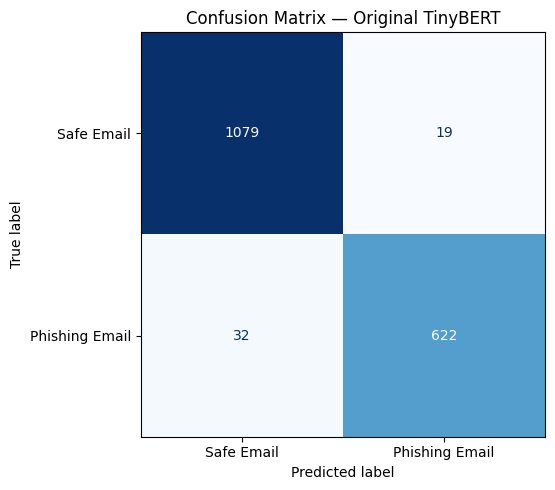

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

cm = np.array([
    [1079, 19],
    [32, 622]
])

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe Email", "Phishing Email"]
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False
)

ax.set_title("Confusion Matrix — Original TinyBERT")
plt.tight_layout()
plt.show()

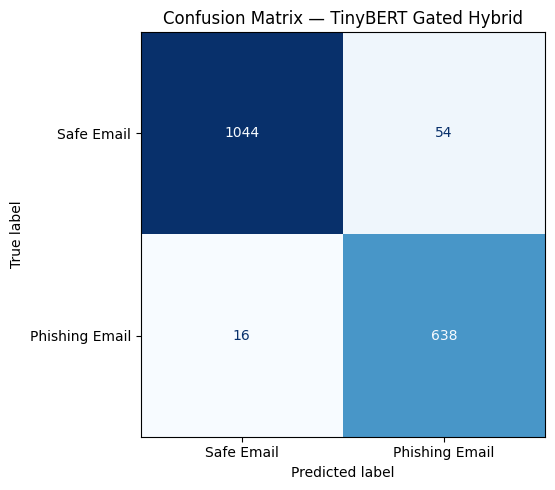

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

cm = np.array([
    [1044, 54],
    [16, 638]
])

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe Email", "Phishing Email"]
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False
)

ax.set_title("Confusion Matrix — TinyBERT Gated Hybrid")
plt.tight_layout()
plt.show()

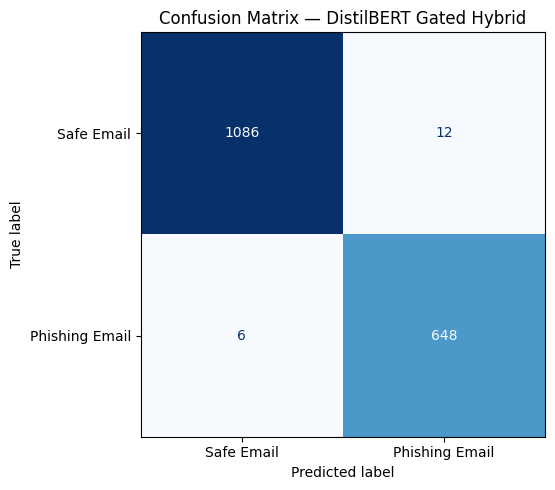

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

cm = np.array([
    [1086, 12],
    [6, 648]
])

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe Email", "Phishing Email"]
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=False
)

ax.set_title("Confusion Matrix — DistilBERT Gated Hybrid")
plt.tight_layout()
plt.show()